# EMS741 Reptile – Fast GPU Meta-Training with Checkpoints and Visuals

This notebook is designed to run on a GPU server (or Colab GPU). It:
- downloads and prepares the EMS741 few-shot segmentation dataset,
- builds a Simple U-Net,
- runs Reptile meta-training with detailed logging and checkpoints,
- loads a chosen checkpoint, and
- evaluates few-shot performance with qualitative images.

## 1. Environment and data

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # Windows OpenMP fix if needed
print('KMP_DUPLICATE_LIB_OK =', os.environ.get('KMP_DUPLICATE_LIB_OK'))

KMP_DUPLICATE_LIB_OK = TRUE


In [2]:
!nvidia-smi -L || echo 'No GPU visible'

GPU 0: NVIDIA A40 (UUID: GPU-258f158f-556e-619c-822d-349eda75d313)


In [3]:
import os, zipfile, urllib.request, glob, random, json, csv, copy
from datetime import datetime

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
from tqdm import tqdm

DATA_URL = 'https://zenodo.org/records/18745413/files/ems741_cw_data.zip?download=1'
ZIP_PATH = 'data.zip'
if not os.path.exists(ZIP_PATH):
    print('Downloading data...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print('Download complete')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall('./')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Tasks and in-memory datasets

In [4]:
TRAIN_ROOT, VAL_ROOT, TEST_ROOT = './train', './val', './test'

def list_tasks(root):
    return sorted([os.path.join(root, d) for d in os.listdir(root) if d.startswith('task_')])

train_tasks = list_tasks(TRAIN_ROOT)
val_tasks   = list_tasks(VAL_ROOT)
test_tasks  = list_tasks(TEST_ROOT)

print('Train tasks:', train_tasks)
print('Val tasks  :', val_tasks)
print('Test tasks :', test_tasks)

class SliceDataset(Dataset):
    def __init__(self, task_root, min_mask_sum=1.0):
        img_dir = os.path.join(task_root, 'images')
        msk_dir = os.path.join(task_root, 'masks')
        img_files = sorted(glob.glob(os.path.join(img_dir, '*.png')))
        msk_files = sorted(glob.glob(os.path.join(msk_dir, '*.png')))
        self.cached = []
        for ip, mp in zip(img_files, msk_files):
            m = np.array(Image.open(mp), dtype=np.float32)
            if m.max() > 1: m = m / 255.0
            if m.sum() >= min_mask_sum:
                img = np.array(Image.open(ip), dtype=np.float32)
                if img.max() > 1: img = img / 255.0
                img = torch.from_numpy(img).float().unsqueeze(0)
                msk = torch.from_numpy(m).float().unsqueeze(0)
                self.cached.append((img, msk))
    def __len__(self):
        return len(self.cached)
    def __getitem__(self, idx):
        return self.cached[idx]

print('Pre-loading slices into RAM...')
cached_datasets = {}
for split, task_list in [('train', train_tasks), ('val', val_tasks), ('test', test_tasks)]:
    for t in tqdm(task_list, desc='Loading {}'.format(split)):
        cached_datasets[t] = SliceDataset(t, min_mask_sum=1.0)
print('Loaded datasets for', len(cached_datasets), 'tasks')

Train tasks: ['./train/task_2', './train/task_3', './train/task_5', './train/task_7']
Val tasks  : ['./val/task_4', './val/task_6']
Test tasks : ['./test/task_1', './test/task_8']
Pre-loading slices into RAM...


Loading test: 100%|██████████| 2/2 [00:01<00:00,  1.69it/s]

Loaded datasets for 8 tasks


## 3. Simple U-Net model

In [5]:
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.c1a = nn.Conv2d(in_channels, 32, 3, padding=1)
        self.c1b = nn.Conv2d(32, 32, 3, padding=1)
        self.p1 = nn.MaxPool2d(2)
        self.c2a = nn.Conv2d(32, 64, 3, padding=1)
        self.c2b = nn.Conv2d(64, 64, 3, padding=1)
        self.p2 = nn.MaxPool2d(2)
        self.c3a = nn.Conv2d(64, 128, 3, padding=1)
        self.c3b = nn.Conv2d(128, 128, 3, padding=1)
        self.p3 = nn.MaxPool2d(2)
        self.c4a = nn.Conv2d(128, 256, 3, padding=1)
        self.c4b = nn.Conv2d(256, 256, 3, padding=1)
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.u1a = nn.Conv2d(256 + 128, 128, 3, padding=1)
        self.u1b = nn.Conv2d(128, 128, 3, padding=1)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.u2a = nn.Conv2d(128 + 64, 64, 3, padding=1)
        self.u2b = nn.Conv2d(64, 64, 3, padding=1)
        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.u3a = nn.Conv2d(64 + 32, 32, 3, padding=1)
        self.u3b = nn.Conv2d(32, 32, 3, padding=1)
        self.out = nn.Conv2d(32, out_channels, 1)
        self.act = nn.ReLU(inplace=True)
        self.final = nn.Sigmoid()
    def forward(self, x):
        x1 = self.act(self.c1b(self.act(self.c1a(x)))); p1 = self.p1(x1)
        x2 = self.act(self.c2b(self.act(self.c2a(p1)))); p2 = self.p2(x2)
        x3 = self.act(self.c3b(self.act(self.c3a(p2)))); p3 = self.p3(x3)
        b  = self.act(self.c4b(self.act(self.c4a(p3))))
        y = self.up1(b); y = torch.cat([y, x3], dim=1); y = self.act(self.u1b(self.act(self.u1a(y))))
        y = self.up2(y); y = torch.cat([y, x2], dim=1); y = self.act(self.u2b(self.act(self.u2a(y))))
        y = self.up3(y); y = torch.cat([y, x1], dim=1); y = self.act(self.u3b(self.act(self.u3a(y))))
        return self.final(self.out(y))

print('Model params:', sum(p.numel() for p in SimpleUNet().parameters()) )

Model params: 1946305


## 4. Losses and metrics

In [6]:
def soft_dice_loss(pred, target, eps=1e-6):
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2 * inter + eps) / (union + eps)
    return 1.0 - dice.mean()

def dice_score(pred, target, eps: float = 1e-6) -> float:
    """
    Compute mean Dice over a batch, with:
      - predictions thresholded at 0.5
      - masks treated as binary (any >0 is foreground)
      - empty-foreground slices ignored
    """
    # Ensure probabilities in [0,1] → threshold at 0.5
    p = (pred > 0.5).float()

    # Ground-truth: treat any positive value as foreground, robust to {0,1} or {0,255}
    t = (target > 0).float()

    # Per-slice Dice
    inter = (p * t).sum(dim=[1, 2, 3])
    union = p.sum(dim=[1, 2, 3]) + t.sum(dim=[1, 2, 3])
    dice_per_slice = (2 * inter + eps) / (union + eps)

    # Ignore slices with empty GT foreground (pure background)
    has_fg = t.sum(dim=[1, 2, 3]) > 0
    if has_fg.any():
        return dice_per_slice[has_fg].mean().item()
    else:
        # If task has no foreground at all, return 0 (or 1.0, depending on convention)
        return 0.0

## 5. Task sampling

In [7]:
def sample_task_episode(task_root, k_support=4, k_query=4):
    ds = cached_datasets[task_root]
    n = len(ds)
    if n == 0:
        raise ValueError('No usable slices in {}'.format(task_root))
    idxs = np.random.permutation(n)
    k_total = min(n, k_support + k_query)
    k_s = min(k_support, k_total // 2)
    k_q = min(k_query, k_total - k_s)
    xs, ys = zip(*[ds[i] for i in idxs[:k_s]])
    xq, yq = zip(*[ds[i] for i in idxs[k_s:k_s+k_q]]) if k_q > 0 else ([], [])
    xs = torch.stack(xs); ys = torch.stack(ys)
    xq = torch.stack(xq) if len(xq) else None
    yq = torch.stack(yq) if len(yq) else None
    return xs, ys, xq, yq

## 6. Inner-loop adaptation (per task)

In [8]:
def inner_update(model, x_s, y_s, steps=3, lr_inner=1e-3, device=device):
    fast = copy.deepcopy(model).to(device)
    opt = torch.optim.SGD(fast.parameters(), lr=lr_inner)
    x_s, y_s = x_s.to(device), y_s.to(device)
    for _ in range(steps):
        opt.zero_grad()
        out = fast(x_s)
        if out.shape != y_s.shape: y_s = y_s.view_as(out)
        loss = 0.1 * F.binary_cross_entropy(out, y_s) + 0.9 * soft_dice_loss(out, y_s) #with weighting
        loss.backward()
        opt.step()
    return fast

## 7. Reptile meta-training with checkpoints

In [ ]:
meta_config = {
    'meta_iters': 50000,       # <-- Set to your big overnight number
    'tasks_per_batch': 4,
    'k_support': 4,
    'k_query': 4,
    'lr_inner': 1e-3,
    'lr_meta': 0.1,
    'inner_steps': 5,
}

checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

def reptile_meta_train(model, train_tasks, device=device):
    model.to(device)
    model.train()
    
    meta_loss_history = []
    total_iters = meta_config['meta_iters']
    
    # --- LOGGING CONFIG ---
    print_every = 200
    save_every = 2500
    # ----------------------
    
    recent_losses = []
    
    for it in range(total_iters):
        iter_start = datetime.now()
        meta_losses = []

        # zero pseudo-gradients
        for p in model.parameters():
            p.grad = torch.zeros_like(p.data)
            
        used_tasks = random.sample(train_tasks, min(meta_config['tasks_per_batch'], len(train_tasks)))
        
        for task_root in used_tasks:
            xs, ys, xq, yq = sample_task_episode(task_root, meta_config['k_support'], meta_config['k_query'])
            
            fast_model = inner_update(model, xs, ys, steps=meta_config['inner_steps'], 
                                      lr_inner=meta_config['lr_inner'], device=device)
            
            if xq is not None and yq is not None:
                xq, yq = xq.to(device), yq.to(device)
                with torch.no_grad():
                    out_q = fast_model(xq)
                    if out_q.shape != yq.shape:
                        yq = yq.view_as(out_q)
                        
                    bce = F.binary_cross_entropy(out_q, yq)
                    dls = soft_dice_loss(out_q, yq)
                    loss_q = bce + dls
                    meta_losses.append(loss_q.item())
            
            # accumulate pseudo-gradients
            for p, pf in zip(model.parameters(), fast_model.parameters()):
                p.grad.data.add_(pf.data - p.data)
                
        # --- LINEAR LR DECAY ---
        # Decays from initial lr_meta down to 0 at the last iteration
        frac_done = it / float(total_iters)
        current_lr_meta = meta_config['lr_meta'] * (1.0 - frac_done)
        
        for p in model.parameters():
            p.grad.data.div_(len(used_tasks))
            # Update using the decayed learning rate
            p.data.add_(current_lr_meta * p.grad.data)
            
        mean_loss = float('nan') if len(meta_losses) == 0 else float(np.mean(meta_losses))
        meta_loss_history.append(mean_loss)
        recent_losses.append(mean_loss)
        
        # Clean logging output
        if (it + 1) % print_every == 0 or it == 0:
            avg_recent_loss = np.mean(recent_losses)
            dt = (datetime.now() - iter_start).total_seconds()
            print(f"Iter {it+1:05d}/{total_iters} | lr_meta: {current_lr_meta:.5f} | Recent Mean Loss: {avg_recent_loss:.4f} | Time/iter: {dt:.2f}s")
            recent_losses = [] # reset accumulator
            
        # Infrequent checkpoints
        if (it + 1) % save_every == 0 or (it + 1) == total_iters:
            ckpt = {
                'model_state': model.state_dict(),
                'meta_loss_history': meta_loss_history,
                'iter': it + 1
            }
            path = os.path.join(checkpoint_dir, f'meta_iter_{it+1}.pt')
            torch.save(ckpt, path)
            print(f" ---> Saved checkpoint: {path}")

    return meta_loss_history

meta_model = SimpleUNet(in_channels=1, out_channels=1).to(device)
meta_loss_history = reptile_meta_train(meta_model, train_tasks, device=device)

Iter 00001/50000 | lr_meta: 0.10000 | Recent Mean Loss: 1.6768 | Time/iter: 0.84s
Iter 00002/50000 | lr_meta: 0.10000 | Recent Mean Loss: 1.6620 | Time/iter: 0.63s
Iter 00003/50000 | lr_meta: 0.10000 | Recent Mean Loss: 1.6705 | Time/iter: 0.61s
Iter 00004/50000 | lr_meta: 0.09999 | Recent Mean Loss: 1.6780 | Time/iter: 0.67s
Iter 00005/50000 | lr_meta: 0.09999 | Recent Mean Loss: 1.6698 | Time/iter: 0.60s
Iter 00006/50000 | lr_meta: 0.09999 | Recent Mean Loss: 1.6727 | Time/iter: 0.68s
Iter 00007/50000 | lr_meta: 0.09999 | Recent Mean Loss: 1.6748 | Time/iter: 0.65s
Iter 00008/50000 | lr_meta: 0.09999 | Recent Mean Loss: 1.6610 | Time/iter: 0.60s
Iter 00009/50000 | lr_meta: 0.09998 | Recent Mean Loss: 1.6685 | Time/iter: 0.60s
Iter 00010/50000 | lr_meta: 0.09998 | Recent Mean Loss: 1.6741 | Time/iter: 0.70s
Iter 00011/50000 | lr_meta: 0.09998 | Recent Mean Loss: 1.6657 | Time/iter: 0.59s
Iter 00012/50000 | lr_meta: 0.09998 | Recent Mean Loss: 1.6723 | Time/iter: 0.61s
Iter 00013/50000

KeyboardInterrupt: 

## 8. Load a chosen checkpoint (optional)

In [10]:
RUN_OPTIONAL_PART_8 = False
if RUN_OPTIONAL_PART_8:
    # Set this to the checkpoint you want to resume/evaluate from
    checkpoint_path = os.path.join('checkpoints', 'meta_iter_4000.pt')  # change if needed

    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        meta_model = SimpleUNet(in_channels=1, out_channels=1).to(device)
        meta_model.load_state_dict(ckpt['model_state'])
        print('Loaded checkpoint from:', checkpoint_path)
        print('Stored iteration index:', ckpt.get('iter'))
        print('Last 10 meta-loss values:', ckpt.get('meta_loss_history', [])[-10:])
    else:
        print('Checkpoint not found at', checkpoint_path, '- using freshly trained meta_model instead.')
else:
    print('Skipping optional part 8 (set RUN_OPTIONAL_PART_8=True to enable).')

Skipping optional part 8 (set RUN_OPTIONAL_PART_8=True to enable).


In [11]:
# Sanity check Dice on one validation task using fixed dice_score

test_task = "./val/task_6"   # or "./val/task_4"
ds = cached_datasets[test_task]

# 4-shot “support” and 32-query evaluation
import numpy as np, copy, torch, torch.nn.functional as F

idxs = np.random.permutation(len(ds))
support_idx = idxs[:4]
query_idx   = idxs[4:36]

xs, ys = zip(*[ds[i] for i in support_idx])
xq, yq = zip(*[ds[i] for i in query_idx])

xs, ys = torch.stack(xs).to(device), torch.stack(ys).to(device)
xq, yq = torch.stack(xq).to(device), torch.stack(yq).to(device)

adapted = copy.deepcopy(meta_model).to(device)
opt = torch.optim.SGD(adapted.parameters(), lr=1e-3)

for _ in range(5):  # same as eval steps
    opt.zero_grad()
    out = adapted(xs)
    loss = F.binary_cross_entropy(out, ys.view_as(out)) + soft_dice_loss(out, ys.view_as(out))
    loss.backward()
    opt.step()

with torch.no_grad():
    pred_q = adapted(xq)

# --- DEBUG PRINTS START ---
print(f"Pred max: {out.max().item():.4f}, Pred min: {out.min().item():.4f}")
print(f"Target pos pixels: {yq.sum().item():.1f}")
print(f"Pred pos pixels (>0.5): {(out > 0.5).sum().item()}")
# --- DEBUG PRINTS END ---

print("Fixed Dice on", test_task, ":", dice_score(pred_q, yq))

Pred max: 0.4744, Pred min: 0.4709
Target pos pixels: 40970.4
Pred pos pixels (>0.5): 0
Fixed Dice on ./val/task_6 : 1.233085744622997e-09


## 9. Few-shot evaluation with qualitative images

Running evaluation on all validation tasks...
Task task_4 | 1-shot Dice: 0.0000


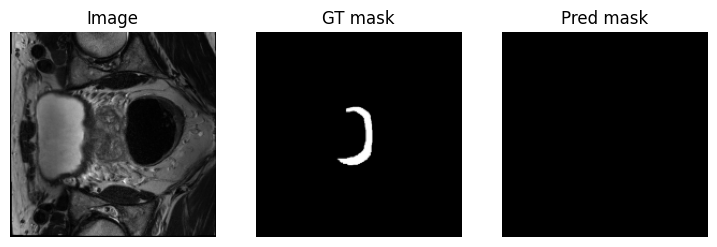

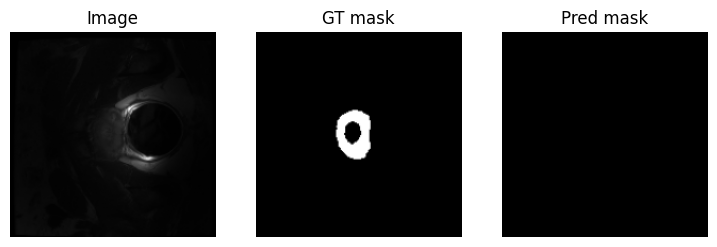

Task task_4 | 3-shot Dice: 0.0000


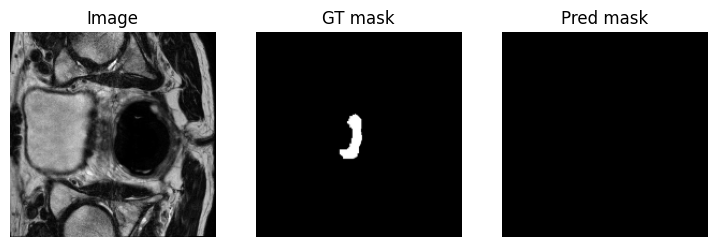

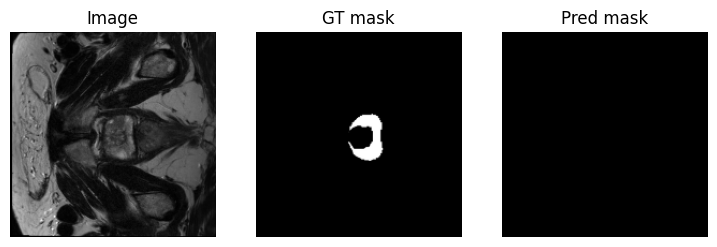

Task task_4 | 5-shot Dice: 0.0000


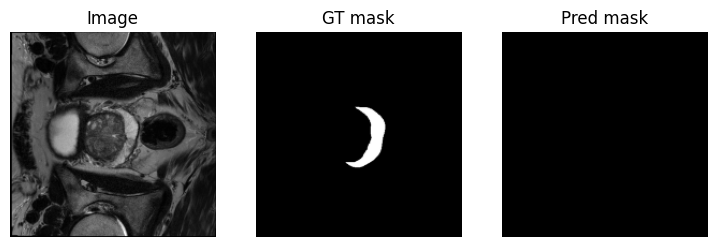

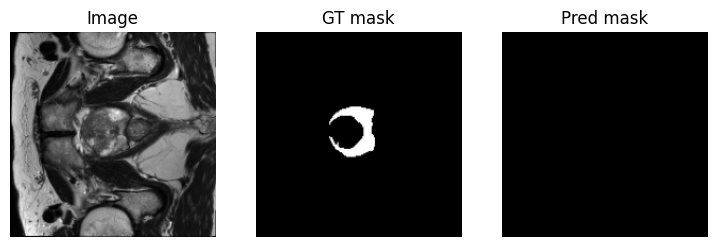

Task task_6 | 1-shot Dice: 0.0000


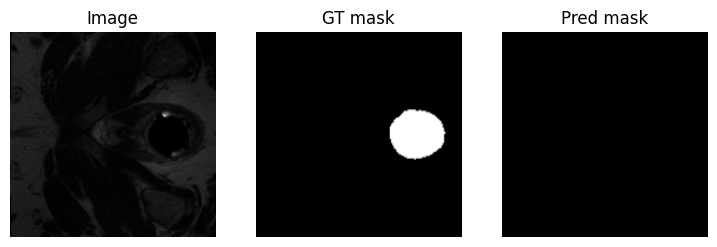

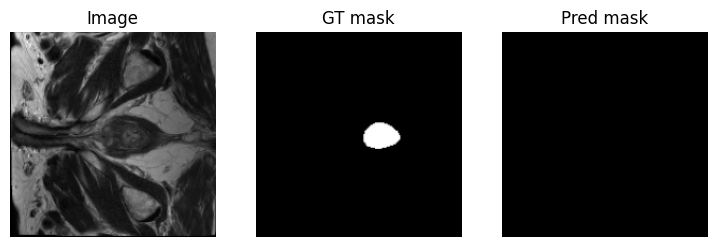

Task task_6 | 3-shot Dice: 0.0000


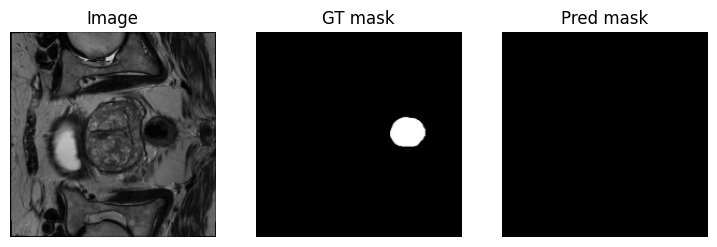

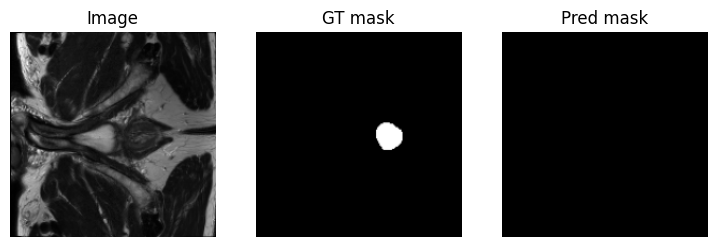

Task task_6 | 5-shot Dice: 0.0000


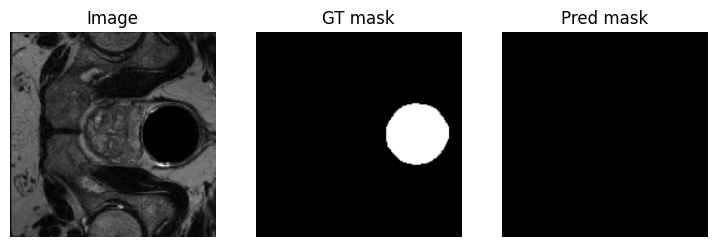

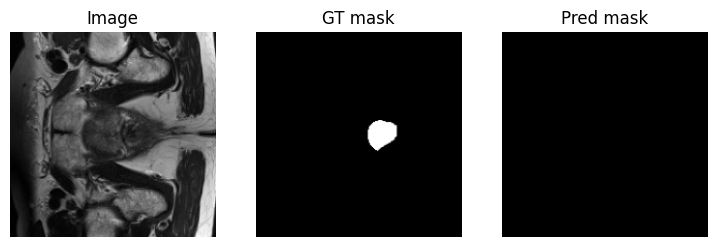

In [12]:
# Global store for evaluation runs
if 'ALL_EVAL_RESULTS' not in globals():
    ALL_EVAL_RESULTS = []

def eval_task_with_images_and_log(model, task_root, shots=4, steps=10, lr_inner=1e-3, device=device, n_vis=3, batch_size=8):
    ds = cached_datasets[task_root]
    n = len(ds)
    if n <= shots:
        raise ValueError('Not enough slices in {}'.format(task_root))
    
    idxs = np.random.permutation(n)
    xs, ys = zip(*[ds[i] for i in idxs[:shots]])
    xs, ys = torch.stack(xs).to(device), torch.stack(ys).to(device)
    
    query_idxs = idxs[shots:]
    
    adapted = copy.deepcopy(model).to(device)
    opt = torch.optim.SGD(adapted.parameters(), lr=lr_inner)
    
    for _ in range(steps):
        opt.zero_grad()
        out_s = adapted(xs)
        if out_s.shape != ys.shape: ys = ys.view_as(out_s)
        loss = F.binary_cross_entropy(out_s, ys) + soft_dice_loss(out_s, ys)
        loss.backward()
        opt.step()
    
    # Batched query eval to prevent OOM
    all_batch_imgs = []  
    all_batch_gts  = []
    all_batch_preds= []
    
    with torch.no_grad():
        for i in range(0, len(query_idxs), batch_size):
            end = min(i + batch_size, len(query_idxs))
            xq_b, yq_b = zip(*[ds[j] for j in query_idxs[i:end]])
            xq_b, yq_b = torch.stack(xq_b).to(device), torch.stack(yq_b).to(device)
            
            out_q_b = adapted(xq_b)
            
            # Store everything on CPU to save VRAM
            all_batch_imgs.append(xq_b.cpu())
            all_batch_gts.append(yq_b.cpu())
            all_batch_preds.append(out_q_b.cpu())

    # Reconstruct full volume on CPU to fix the Dice math
    full_xq = torch.cat(all_batch_imgs, dim=0)
    full_yq = torch.cat(all_batch_gts, dim=0)
    full_out_q = torch.cat(all_batch_preds, dim=0)
    
    mean_dice = dice_score(full_out_q, full_yq)
    print('Task {} | {}-shot Dice: {:.4f}'.format(os.path.basename(task_root), shots, mean_dice))
    
    # Save visuals
    results_root = 'results'
    img_dir = os.path.join(results_root, 'images')
    os.makedirs(img_dir, exist_ok=True)
    saved_paths = []
    
    k = min(n_vis, full_xq.shape[0])
    for i in range(k):
        img = full_xq[i,0].numpy()
        gt  = full_yq[i,0].numpy()
        pr  = (full_out_q[i,0].numpy() > 0.5).astype(float)
        
        base = 'task_{}_shots_{}_idx_{}'.format(os.path.basename(task_root), shots, i)
        img_path  = os.path.join(img_dir, base + '_img.png')
        gt_path   = os.path.join(img_dir, base + '_gt.png')
        pred_path = os.path.join(img_dir, base + '_pred.png')
        
        plt.imsave(img_path, img, cmap='gray')
        plt.imsave(gt_path,  gt,  cmap='gray')
        plt.imsave(pred_path, pr, cmap='gray')
        saved_paths.extend([img_path, gt_path, pred_path])
        
        fig, axs = plt.subplots(1,3,figsize=(9,3))
        axs[0].imshow(img, cmap='gray'); axs[0].set_title('Image'); axs[0].axis('off')
        axs[1].imshow(gt, cmap='gray'); axs[1].set_title('GT mask'); axs[1].axis('off')
        axs[2].imshow(pr, cmap='gray'); axs[2].set_title('Pred mask'); axs[2].axis('off')
        plt.show()

    ALL_EVAL_RESULTS.append({
        'task': task_root,
        'shots': int(shots),
        'dice': float(mean_dice),
        'image_paths': saved_paths,
    })
    
    return mean_dice

# ==== RUN FULL EVALUATION ====
print('Running evaluation on all validation tasks...')

# Define evaluation parameters here as variables
eval_steps_used = 5
eval_lr_used = 1e-3
eval_batch_size_used = 8
n_vis_used = 2

for t in val_tasks:
    for s in [1, 3, 5]:
        eval_task_with_images_and_log(
            meta_model, 
            t, 
            shots=s, 
            steps=eval_steps_used, 
            lr_inner=eval_lr_used, 
            device=device, 
            n_vis=n_vis_used,
            batch_size=eval_batch_size_used
        )

## 10. Save results (images + metrics) as a ZIP

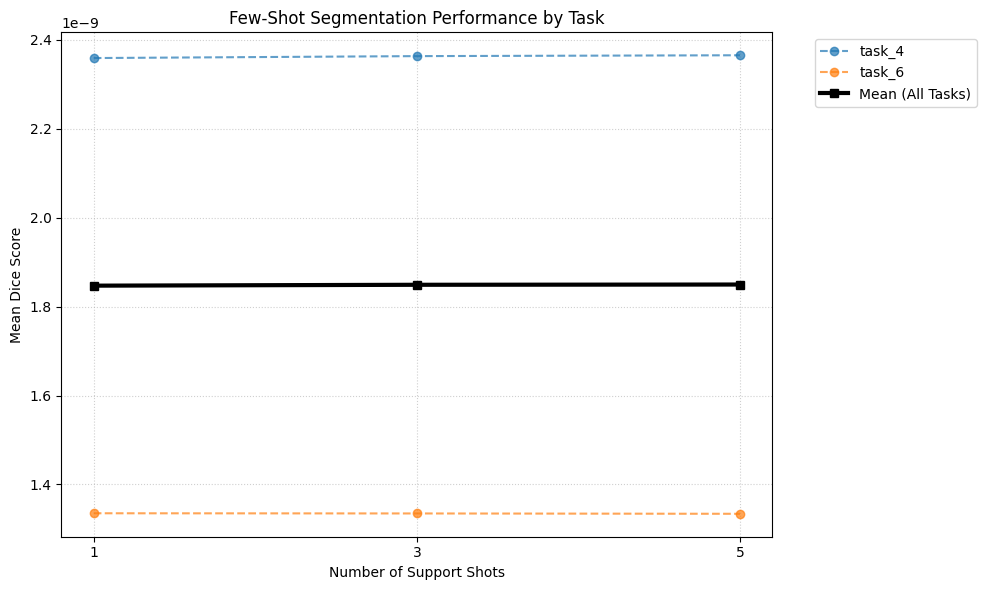

Saved results ZIP to results/EMS741_iters1_steps5_dice0.0000_20260327_034740.zip


In [13]:
# === 10. Aggregate results, generate plots, and Save as ZIP ===
import json
import zipfile
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

results_root = "results"
os.makedirs(results_root, exist_ok=True)
graph_path = os.path.join(results_root, 'dice_vs_shots.png')

# 1. Generate Plots from ALL_EVAL_RESULTS
if 'ALL_EVAL_RESULTS' in globals() and len(ALL_EVAL_RESULTS) > 0:
    # Group results by task and shots
    tasks = sorted(list(set(r['task'] for r in ALL_EVAL_RESULTS)))
    shots_list = sorted(list(set(r['shots'] for r in ALL_EVAL_RESULTS)))
    
    plt.figure(figsize=(10, 6))
    
    # Plot individual tasks
    for t in tasks:
        task_name = os.path.basename(t)
        task_data = [r for r in ALL_EVAL_RESULTS if r['task'] == t]
        task_data.sort(key=lambda x: x['shots'])
        
        x = [r['shots'] for r in task_data]
        y = [r['dice'] for r in task_data]
        plt.plot(x, y, marker='o', linestyle='--', alpha=0.7, label=task_name)
    
    # Calculate and plot the mean across all tasks
    mean_y = []
    for s in shots_list:
        dice_vals = [r['dice'] for r in ALL_EVAL_RESULTS if r['shots'] == s]
        mean_y.append(np.mean(dice_vals) if dice_vals else 0)
        
    plt.plot(shots_list, mean_y, marker='s', linewidth=3, color='black', label='Mean (All Tasks)')
        
    plt.title('Few-Shot Segmentation Performance by Task')
    plt.xlabel('Number of Support Shots')
    plt.ylabel('Mean Dice Score')
    plt.xticks(shots_list)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Save the figure to include in the ZIP, then show it
    plt.savefig(graph_path, dpi=150)
    plt.show()

    best_dice = max(r['dice'] for r in ALL_EVAL_RESULTS)
else:
    best_dice = 0.0
    print("No evaluation results found to plot.")

# 2. Save JSON summary
now_str = datetime.now().strftime('%Y%m%d_%H%M%S')
meta_iters = meta_config['meta_iters'] if 'meta_config' in globals() else 'NA'
zip_name = f"EMS741_iters{meta_iters}_steps{eval_steps_used}_dice{best_dice:.4f}_{now_str}.zip"
zip_path = os.path.join(results_root, zip_name)

summary_path = os.path.join(results_root, 'summary.json')
run_config = {
    "meta_config": globals().get('meta_config', {}),
    "eval_config": {
        "eval_steps": globals().get('eval_steps_used', 5),
        "eval_lr_inner": globals().get('eval_lr_used', 1e-3),
        "eval_batch_size": globals().get('eval_batch_size_used', 8),
        "n_vis_per_task": globals().get('nvis_used', 2),
    },
    "best_dice": best_dice,
    "results": globals().get('ALL_EVAL_RESULTS', [])
}

with open(summary_path, 'w') as f:
    json.dump(run_config, f, indent=2)

# 3. Build ZIP
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    # Add summary.json
    if os.path.exists(summary_path):
        zf.write(summary_path, arcname=os.path.basename(summary_path))
    
    # Add the generated graph
    if os.path.exists(graph_path):
        zf.write(graph_path, arcname=os.path.basename(graph_path))
        
    # Add all images from the results/images directory
    img_dir = os.path.join(results_root, 'images')
    if os.path.isdir(img_dir):
        for root, _, files in os.walk(img_dir):
            for fname in files:
                full = os.path.join(root, fname)
                rel = os.path.relpath(full, results_root)
                zf.write(full, arcname=rel)

print(f"Saved results ZIP to {zip_path}")